# Visualisation for the Coarse Results

In [34]:
# Prerequisites 
import pandas as pd
import numpy as np
import os
import yaml
import json
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

def extract_metric(cell, metric):
    if isinstance(cell, dict):
        return cell.get(metric, None)
    try:
        d = ast.literal_eval(cell)
        return d.get(metric, None)
    except Exception:
        return None
    
def extract_metric_dict(cell):
    """Ensure the cell is a dictionary (convert from string if necessary)."""
    if isinstance(cell, dict):
        return cell
    try:
        return ast.literal_eval(cell)
    except Exception:
        return {}

def get_matching_df(df):
    """
    Given a DataFrame where the index and columns are scan IDs and each cell is a dictionary
    of metrics, return a new DataFrame containing only the diagonal cells.
    """
    diag_data = {}
    # Iterate over each scan in the index.
    for scan in df.index:
        if scan in df.columns:
            cell = df.loc[scan, scan]
            diag_data[scan] = extract_metric_dict(cell)
    # Create a new DataFrame from the nested dictionary.
    diag_df = pd.DataFrame.from_dict(diag_data, orient='index')
    return diag_df

## 1. Load dataframe

In [35]:
# Load config
# config_path = "/app/bindmount/gedi_data_2/config.yaml"
#config_path = "/app/bindmount/gedi_data_real_scan/config_real_scan.yaml"
config_path = "/app/bindmount/gedi_data_real_scan_5x315/config_real_scan_5x315.yaml"
with open(config_path, "r") as file:
        config = yaml.safe_load(file)

base = config["base"]
coarse_score_df = config["paths"]["results"]["filtering_coarse_overall"]
file_name = config["paths"]["results"]["filtering_coarse_overall_file_name"]

df_path = os.path.join(base, coarse_score_df, file_name)
coarse_score_df = pd.read_json(df_path)
coarse_score_df

,1,778817,779632,785583,793998,763620,763621,763638,763640,763660,...,8179629,8179631,8181146,8181152,8181354,8181356,8186079,8188922,8188926,8188996
1,"{'score_sim1': 0.0385640072, 'score_sim2': 0.1...","{'score_sim1': 0.1278184357, 'score_sim2': 33....","{'score_sim1': 0.111504374, 'score_sim2': 4.27...","{'score_sim1': 0.08406836270000001, 'score_sim...","{'score_sim1': 0.0873321866, 'score_sim2': 0.4...","{'score_sim1': 0.1264163054, 'score_sim2': 17....","{'score_sim1': 0.1264402583, 'score_sim2': 17....","{'score_sim1': 0.054510890900000004, 'score_si...","{'score_sim1': 0.1530594314, 'score_sim2': 0.5...","{'score_sim1': 0.1311361336, 'score_sim2': 81....",...,"{'score_sim1': 0.12648343010000002, 'score_sim...","{'score_sim1': 0.1331162202, 'score_sim2': 0.6...","{'score_sim1': 0.0391120783, 'score_sim2': 0.1...","{'score_sim1': 0.11149396980000001, 'score_sim...","{'score_sim1': 0.107020902, 'score_sim2': 2.36...","{'score_sim1': 0.0971118494, 'score_sim2': 2.1...","{'score_sim1': 0.060593686800000005, 'score_si...","{'score_sim1': 0.1253451277, 'score_sim2': 17....","{'score_sim1': 0.1287426928, 'score_sim2': 37....","{'score_sim1': 0.12952744800000002, 'score_sim..."
778817,"{'score_sim1': 0.1250062683, 'score_sim2': 0.9...","{'score_sim1': 0.0013660285, 'score_sim2': 0.2...","{'score_sim1': 0.021557383700000002, 'score_si...","{'score_sim1': 0.0578336827, 'score_sim2': 1.0...","{'score_sim1': 0.1749558626, 'score_sim2': 1.1...","{'score_sim1': 0.0043318476, 'score_sim2': 0.6...","{'score_sim1': 0.0043086725, 'score_sim2': 0.6...","{'score_sim1': 0.0751919842, 'score_sim2': 0.9...","{'score_sim1': 0.23996261970000002, 'score_sim...","{'score_sim1': 0.0046630306000000005, 'score_s...",...,"{'score_sim1': 0.21410710600000002, 'score_sim...","{'score_sim1': 0.2207398962, 'score_sim2': 1.2...","{'score_sim1': 0.12067941100000001, 'score_sim...","{'score_sim1': 0.0184055705, 'score_sim2': 0.8...","{'score_sim1': 0.0482937367, 'score_sim2': 1.2...","{'score_sim1': 0.0337687556, 'score_sim2': 0.9...","{'score_sim1': 0.14809400720000002, 'score_sim...","{'score_sim1': 0.0036261654000000003, 'score_s...","{'score_sim1': 0.0023929454, 'score_sim2': 0.6...","{'score_sim1': 0.0031777005, 'score_sim2': 1.2..."
779632,"{'score_sim1': 0.1178475462, 'score_sim2': 0.9...","{'score_sim1': 0.016037626, 'score_sim2': 4.48...","{'score_sim1': 0.0090608719, 'score_sim2': 0.3...","{'score_sim1': 0.046452449800000004, 'score_si...","{'score_sim1': 0.1639887569, 'score_sim2': 1.0...","{'score_sim1': 0.0146354957, 'score_sim2': 2.1...","{'score_sim1': 0.014659448600000001, 'score_si...","{'score_sim1': 0.0681273023, 'score_sim2': 0.8...","{'score_sim1': 0.23234297040000002, 'score_sim...","{'score_sim1': 0.0193553238, 'score_sim2': 12....",...,"{'score_sim1': 0.2016105943, 'score_sim2': 1.2...","{'score_sim1': 0.2082433844, 'score_sim2': 1.2...","{'score_sim1': 0.11053834480000001, 'score_sim...","{'score_sim1': 0.007884018500000001, 'score_si...","{'score_sim1': 0.035797225, 'score_sim2': 0.91...","{'score_sim1': 0.0267040737, 'score_sim2': 0.7...","{'score_sim1': 0.1379529411, 'score_sim2': 1.1...","{'score_sim1': 0.012311150100000001, 'score_si...","{'score_sim1': 0.016564327900000002, 'score_si...","{'score_sim1': 0.0174866215, 'score_sim2': 7.6..."
785583,"{'score_sim1': 0.10409182880000001, 'score_sim...","{'score_sim1': 0.0454882795, 'score_sim2': 12....","{'score_sim1': 0.026196147000000003, 'score_si...","{'score_sim1': 0.0240054848, 'score_sim2': 0.3...","{'score_sim1': 0.14112766470000002, 'score_sim...","{'score_sim1': 0.0440861492, 'score_sim2': 6.3...","{'score_sim1': 0.0441101021, 'score_sim2': 6.3...","{'score_sim1': 0.054371584800000004, 'score_si...","{'score_sim1': 0.218587253, 'score_sim2': 0.88...","{'score_sim1': 0.0488059774, 'score_sim2': 31....",...,"{'score_sim1': 0.1802789082, 'score_sim2': 1.0...","{'score_sim1': 0.1869116983, 'score_sim2': 1.0...","{'score_sim1': 0.08700975200000001, 'score_sim...","{'score_sim1':

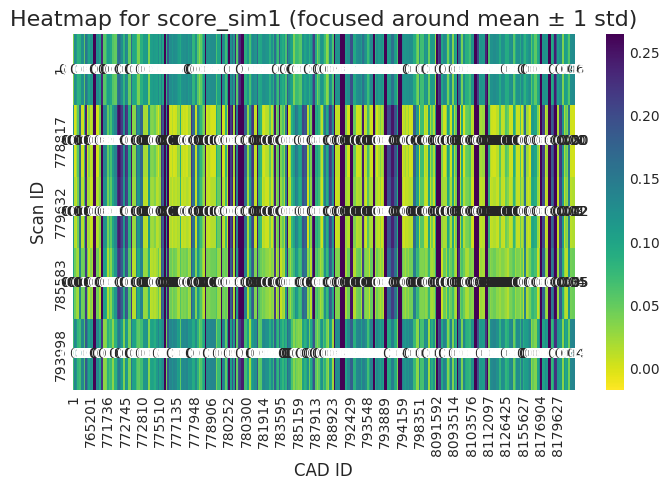

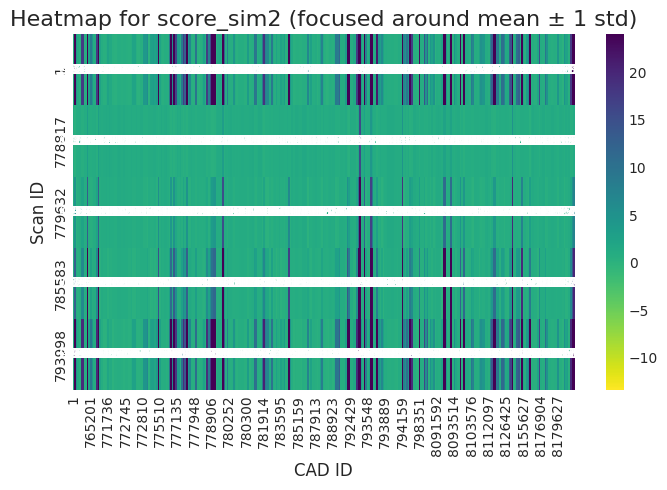

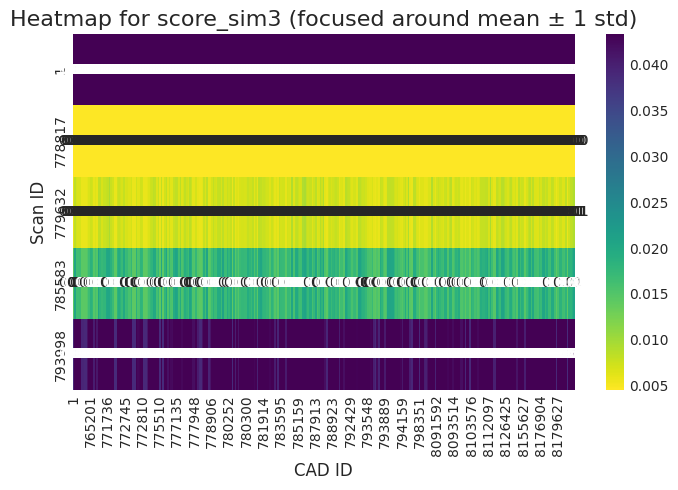

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

def extract_metric(cell, metric):
    if cell is None:
        return None
    if isinstance(cell, dict):
        return cell.get(metric, None)
    try:
        d = ast.literal_eval(cell)
        return d.get(metric, None)
    except Exception:
        return None

def plot_heatmap(df_metric, title, focus_factor=1.0, figsize=(7, 5), cmap="viridis_r", output_file=None):
    # Compute global mean and std from all values in the DataFrame.
    global_mean = df_metric.stack().mean()
    global_std = df_metric.stack().std()
    # Focus the color scale around the mean.
    vmin = global_mean - focus_factor * global_std
    vmax = global_mean + focus_factor * global_std

    plt.figure(figsize=figsize)
    sns.heatmap(df_metric, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title, fontsize=16)
    plt.xlabel("CAD ID", fontsize=12)
    plt.ylabel("Scan ID", fontsize=12)
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Heatmap saved to {output_file}")
    plt.show()

# Assuming coarse_score_df is your loaded DataFrame, where cells are dictionaries.
df_sim1 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim1"))
df_sim2 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim2"))
df_sim3 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim3"))

plot_heatmap(df_sim1, "Heatmap for score_sim1 (focused around mean ± 1 std)", focus_factor=1.0)
plot_heatmap(df_sim2, "Heatmap for score_sim2 (focused around mean ± 1 std)", focus_factor=1.0)
plot_heatmap(df_sim3, "Heatmap for score_sim3 (focused around mean ± 1 std)", focus_factor=1.0)

### 1.1 Describe all the scores
No matter if it's a match or no, we take all the scores

In [37]:
# Assume 'coarse_score_df' is your original DataFrame with scan IDs as index 
# and CAD IDs as columns, each cell being a dict with keys like "score_sim1", etc.
# Extract and stack the metrics into Series, then create a new DataFrame.
df_sim1 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim1")).stack().reset_index(drop=True)
df_sim2 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim2")).stack().reset_index(drop=True)
df_sim3 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim3")).stack().reset_index(drop=True)

df_metrics = pd.DataFrame({
    "score_sim1": df_sim1,
    "score_sim2": df_sim2,
    "score_sim3": df_sim3
})

# THIS IS THE SCORES DATAFRAME
# SCORE STATS
df_metrics.describe()

,score_sim1,score_sim2,score_sim3
count,1595.000000,1595.000000,1595.000000
mean,0.123734,5.311353,0.023906
std,0.140518,18.697884,0.019332
min,0.001366,0.039936,0.001531
25%,0.036360,0.735075,0.006478
50%,0.095189,1.070226,0.017174
75%,0.137470,2.213815,0.044194
max,1.051860,390.222264,0.059542


### 1.2 Describe the scores of the matching scans
This is the metrics of the coarse filtering, but only when there is a match. 

In [38]:
matching_score_df = get_matching_df(coarse_score_df)
matching_score_df.describe()

,score_sim1,score_sim2,score_sim3
count,5.000000,5.000000,5.000000
mean,0.028714,0.293748,0.023248
std,0.027413,0.090872,0.020496
min,0.001366,0.164833,0.002738
25%,0.009061,0.233389,0.007107
50%,0.024005,0.343009,0.016376
75%,0.038564,0.347312,0.043472
max,0.070576,0.380195,0.046549


## Rank analysis

### Load the data
This is the rank we evaluate here **not the scores of the ranks**

In [39]:
folder = config["paths"]["results"]["filtering_coarse_rank"]
file = config["paths"]["results"]["filtering_coarse_rank_file_name"]


df_path = os.path.join(base, folder, file)
coarse_rank_df = pd.read_json(df_path)
coarse_rank_df

,score_sim1
1,1
778817,1
779632,1
785583,1
793998,1


In [40]:
desc = coarse_rank_df.describe()
desc.loc["95%"] = coarse_rank_df.quantile(0.95)
desc.loc["99%"] = coarse_rank_df.quantile(0.99)
desc

,score_sim1
count,5.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0
95%,1.0
99%,1.0


/tmp/ipykernel_30530/4211914929.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


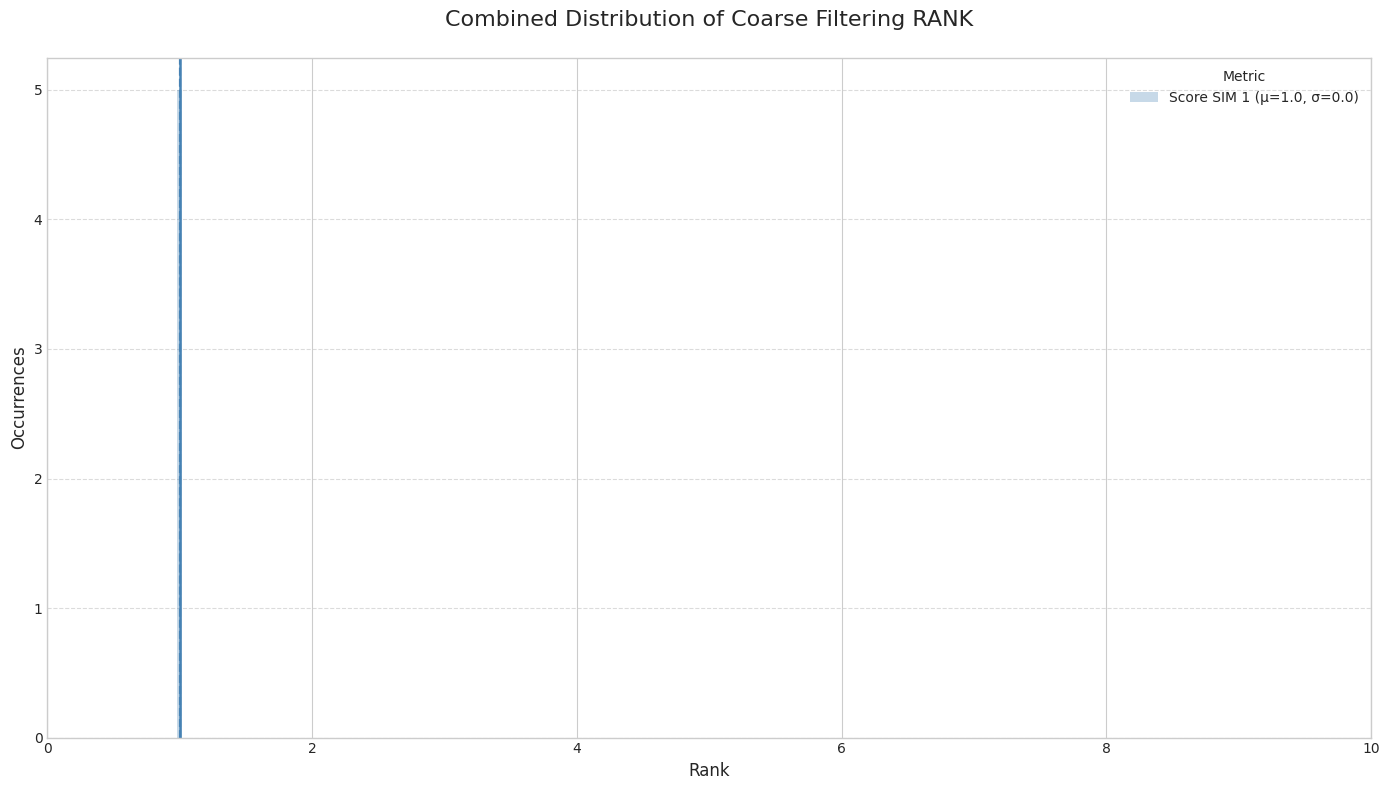

In [41]:
# Set the seaborn-whitegrid theme
plt.style.use('seaborn-whitegrid')

# Define the metrics, display titles, and colors
metrics = ["score_sim1", "score_sim2", "score_sim3"]
titles = ["Score SIM 1"]
colors = ["steelblue", "darkorange", "mediumseagreen"]

# Create a single figure and axis
plt.figure(figsize=(14, 8))

# Loop over each metric to plot its distribution
for metric, label, color in zip(metrics, titles, colors):
    # Get the metric data from the DataFrame (assumed to be coarse_rank_df)
    data = coarse_rank_df[metric]
    m = data.mean()
    s = data.std()
    # Filter data within [mean - std, mean + std]
    filtered = data[(data >= m - s) & (data <= m + s)]
    
    # Plot histogram with KDE overlay (filled, translucent)
    sns.histplot(filtered, bins=25, kde=True, stat="count",
                 label=f"{label} (μ={m:.1f}, σ={s:.1f})",
                 color=color, fill=True, alpha=0.3, linewidth=0)
    
    # Add vertical lines for the mean and ± standard deviation
    plt.axvline(m, color=color, linestyle='-', linewidth=1.8)
    plt.axvline(m - s, color=color, linestyle='--', linewidth=1.5)
    plt.axvline(m + s, color=color, linestyle='--', linewidth=1.5)

# Final plot styling
plt.title("Combined Distribution of Coarse Filtering RANK\n", fontsize=16)
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Occurrences", fontsize=12)
# Optionally, adjust x-axis limits based on your data; for example:
plt.xlim(0, 10)
plt.legend(title="Metric", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [42]:
import ast

def get_matching_df(df):
    diag_values = {}
    for scan in df.index:
        if scan in df.columns:
            cell = df.loc[scan, scan]
            diag_values[scan] = {
                "score_sim1": extract_metric(cell, "score_sim1"),
                "score_sim2": extract_metric(cell, "score_sim2"),
                "score_sim3": extract_metric(cell, "score_sim3")
            }
    return pd.DataFrame.from_dict(diag_values, orient="index")

# Extract the diagonal values (the "match" for each scan)
matching_score_df = get_matching_df(coarse_score_df)
desc = matching_score_df.describe()
desc.loc["95%"] = matching_score_df.quantile(0.95)
desc.loc["99%"] = matching_score_df.quantile(0.99)
desc



,score_sim1,score_sim2,score_sim3
count,5.000000,5.000000,5.000000
mean,0.028714,0.293748,0.023248
std,0.027413,0.090872,0.020496
min,0.001366,0.164833,0.002738
25%,0.009061,0.233389,0.007107
50%,0.024005,0.343009,0.016376
75%,0.038564,0.347312,0.043472
max,0.070576,0.380195,0.046549
95%,0.064174,0.373618,0.045934
99%,0.069296,0.378879,0.046426


/tmp/ipykernel_30530/1576681977.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


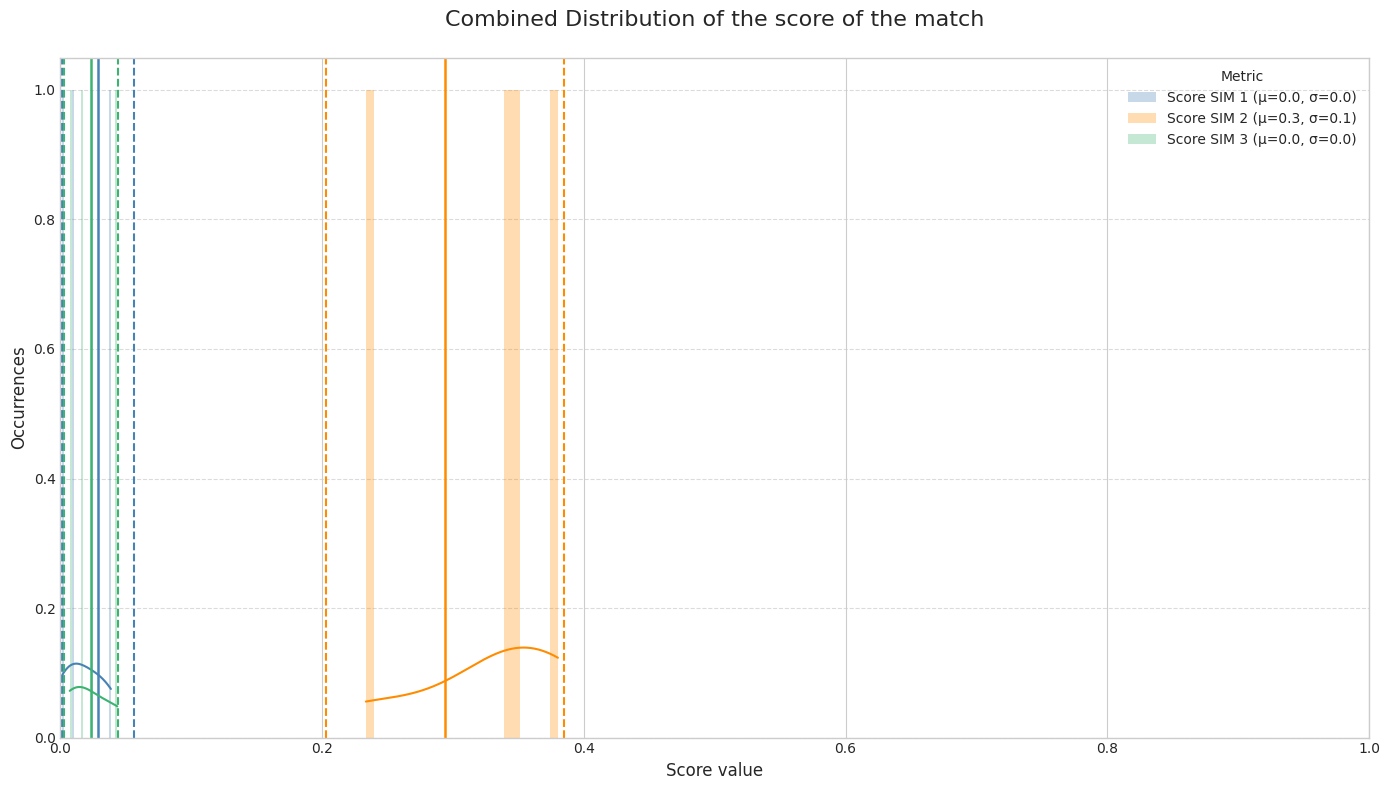

In [43]:
# Set the seaborn-whitegrid theme
plt.style.use('seaborn-whitegrid')

# Define the metrics, display titles, and colors
metrics = ["score_sim1", "score_sim2", "score_sim3"]
titles = ["Score SIM 1", "Score SIM 2", "Score SIM 3"]
colors = ["steelblue", "darkorange", "mediumseagreen"]

# Create a single figure and axis
plt.figure(figsize=(14, 8))

# Loop over each metric to plot its distribution
for metric, label, color in zip(metrics, titles, colors):
    # Get the metric data from the DataFrame
    data = matching_score_df[metric]
    m = data.mean()
    s = data.std()
    # Filter data within [mean - std, mean + std]
    filtered = data[(data >= m - s) & (data <= m + s)]
    
    # Plot histogram with KDE overlay (filled, translucent)
    sns.histplot(filtered, bins=25, kde=True, stat="count",
                 label=f"{label} (μ={m:.1f}, σ={s:.1f})",
                 color=color, fill=True, alpha=0.3, linewidth=0)
    
    # Add vertical lines for the mean and ± standard deviation
    plt.axvline(m, color=color, linestyle='-', linewidth=1.8)
    plt.axvline(m - s, color=color, linestyle='--', linewidth=1.5)
    plt.axvline(m + s, color=color, linestyle='--', linewidth=1.5)

# Final plot styling
plt.title("Combined Distribution of the score of the match\n", fontsize=16)
plt.xlabel("Score value", fontsize=12)
plt.ylabel("Occurrences", fontsize=12)
# Optionally, adjust x-axis limits based on your data; for example:
plt.xlim(0, 1)
plt.legend(title="Metric", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()